# **Abstract**

Este proyecto analiza datos de encuestas de satisfacción de clientes de un centro de atención. El objetivo es identificar qué factores influyen en la experiencia del cliente y en su probabilidad de recomendar el servicio, medida a través del Net Promoter Score (NPS).

Mediante técnicas de análisis exploratorio de datos (EDA) y visualizaciones en Python, se examinan variables relacionadas con la resolución del caso, la demora percibida y la cordialidad del agente. Los resultados del análisis permiten identificar oportunidades de mejora en la operación del centro de atención y en la experiencia del cliente.

# **Preguntas del análisis**

¿Cómo se distribuyen las respuestas de NPS de los clientes?

¿La resolución del caso influye en la recomendación del servicio?

¿Cómo perciben los clientes la demora en la atención?

¿Cómo evalúan los clientes la cordialidad del agente?

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [124]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
csv_file_path = '/content/drive/MyDrive/NPS-RES.csv'
df = pd.read_csv(csv_file_path)

In [126]:
df.head(10)

,Fecha de inicio (+00:00 GMT),Fecha de finalización (+00:00 GMT),Tipo de respuesta,Dirección IP,Progreso,Duración (en segundos),Finalizado,Fecha registrada (+00:00 GMT),Apellido del destinatario,Nombre del destinatario,...,Contactos_X_Casos,SegmentoPay,Agrupación de Tags,CaseID Nuevo,_cachedDate (+00:00 GMT),_recordId,_recordedDate (+00:00 GMT),_sourceId,_sourceMapId,_sourceType
0,2025-06-11 18:50:41,2025-06-11 18:53:29,Dirección IP,181.167.252.16,100,168,Verdadero,2025-06-11 18:53:29,NaN,NaN,...,NaN,NaN,Sin categoría,102708418,2026-03-08 03:00:15,R_7lghsYJ5JOkiZ8I,2025-06-11 18:53:29,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
1,2025-03-19 18:20:38,2025-03-19 18:22:06,Dirección IP,186.139.103.112,100,87,Verdadero,2025-03-19 18:22:06,NaN,NaN,...,NaN,NaN,Sin categoría,102360590,2026-03-08 03:00:15,R_50eJEPdIBCNrHE2,2025-03-19 18:22:06,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
2,2025-02-25 11:27:18,2025-02-25 11:28:30,Dirección IP,181.9.212.86,100,72,Verdadero,2025-02-25 11:28:30,NaN,NaN,...,NaN,NaN,Sin categoría,102626109,2026-03-08 03:00:15,R_3VI1e2JSsoPw0CJ,2025-02-25 11:28:30,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
3,2025-02-18 00:51:09,2025-02-18 00:52:05,Dirección IP,181.46.176.30,100,56,Verdadero,2025-02-18 00:52:05,NaN,NaN,...,NaN,NaN,Sin categoría,102879679,2026-03-08 03:00:15,R_338cNVPjJNn8lih,2025-02-18 00:52:05,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
4,2025-02-06 10:22:33,2025-02-06 10:23:31,Dirección IP,181.85.42.174,100,57,Verdadero,2025-02-06 10:23:31,NaN,NaN,...,NaN,NaN,Sin categoría,101101866,2026-03-08 03:00:15,R_3VfNBMFLJPBrZ3W,2025-02-06 10:23:31,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
5,2025-01-29 17:34:05,2025-01-29 17:35:10,Dirección IP,181.209.80.116,100,64,Verdadero,2025-01-29 17:35:11,NaN,NaN,...,NaN,NaN,Sin categoría,103282418,2026-03-08 03:00:15,R_1bUU4YtBJGD2Snj,2025-01-29 17:35:11,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
6,2025-01-12 15:07:04,2025-01-12 15:09:39,Dirección IP,45.177.80.203,100,155,Verdadero,2025-01-12 15:09:40,NaN,NaN,...,NaN,NaN,Sin categoría,103794813,2026-03-08 03:00:15,R_1sh6xaRdCXs69Um,2025-01-12 15:09:40,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
7,2025-01-09 14:33:10,2025-01-09 14:33:15,Dirección IP,186.22.16.6,100,5,Verdadero,2025-01-09 14:33:16,NaN,NaN,...,NaN,NaN,Sin categoría,101965057,2026-03-08 03:00:15,R_7O1V0cOU1e5wBqg,2025-01-09 14:33:16,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
8,2025-01-08 21:28:58,2025-01-08 21:30:03,Dirección IP,181.104.128.244,100,65,Verdadero,2025-01-08 21:30:05,NaN,NaN,...,NaN,NaN,Sin categoría,103254661,2026-03-08 03:00:15,R_5qW7MMBsgyUHaiB,2025-01-08 21:30:05,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey
9,2025-01-03 01:13:32,2025-01-03 01:14:51,Dirección IP,181.29.113.200,100,78,Verdadero,2025-01-03 01:14:51,NaN,NaN,...,NaN,NaN,Sin categoría,103702615,2026-03-08 03:00:15,R_6lYSy2AGfT4s5d4,2025-01-03 01:14:51,SV_eFgosaiMed9vLgi,1DD0AF722EF1C81B536A5443F6CAFE7A,survey


In [127]:
df.shape

(1601, 73)

In [128]:
df.columns

Index(['Fecha de inicio (+00:00 GMT)', 'Fecha de finalización (+00:00 GMT)',
       'Tipo de respuesta', 'Dirección IP', 'Progreso',
       'Duración (en segundos)', 'Finalizado', 'Fecha registrada (+00:00 GMT)',
       'Apellido del destinatario', 'Nombre del destinatario',
       'Correo electrónico del destinatario', 'Referencia externa',
       'Latitud de la ubicación', 'Longitud de la ubicación',
       'Canal de la distribución', 'Idioma del usuario', 'NPS_GRUPO',
       'NPS_NUMERO', 'NPS_CA', 'CSAT_ATENCION', 'RESOLUCION', 'RESOLUCION_REF',
       'caseId', 'profileName', 'profileEmail', 'lastPersonUsername',
       'siteName', 'queueId', 'servicesTypes', 'importantTagId',
       'case started on YYYY/MM/dd HH:mm:ss (+00:00 GMT)',
       'importantTagFullName', 'businessData', 'queueName', 'caseTags',
       'siteId', 'lastPersonId', 'profileCellphone', 'profileId',
       'FECHA_CASO (+00:00 GMT)', 'serviceTypes2', 'siteName2',
       'Q28- ¿Sos la persona que se comunicó con

In [138]:
variables = [
'NPS_NUMERO',
'RESOLUCION',
'CSAT_DEMORA',
'CSAT_CORDIALIDAD'
]

df_clean = df[variables]

df_clean = df_clean.dropna()

# **Análisis exploratorio de datos (EDA)**

En esta sección se exploran los datos mediante visualizaciones que permiten identificar patrones y relaciones entre variables relevantes para la experiencia del cliente.

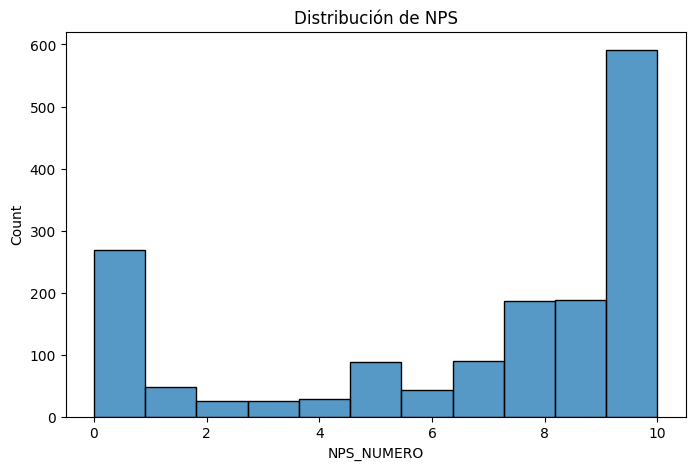

In [139]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean['NPS_NUMERO'], bins=11)

plt.title("Distribución de NPS")

plt.show()

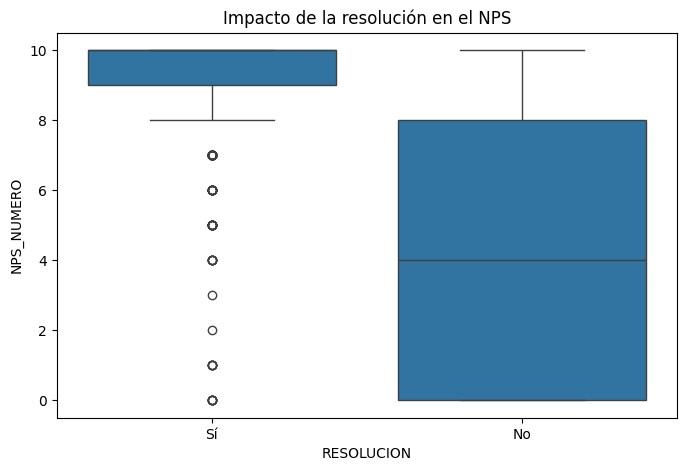

In [140]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df_clean,
x='RESOLUCION',
y='NPS_NUMERO'
)

plt.title("Impacto de la resolución en el NPS")

plt.show()

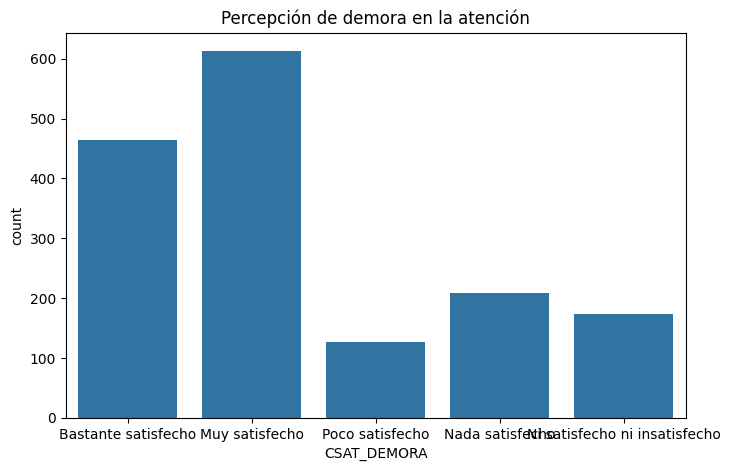

In [141]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df_clean,
x='CSAT_DEMORA'
)

plt.title("Percepción de demora en la atención")

plt.show()

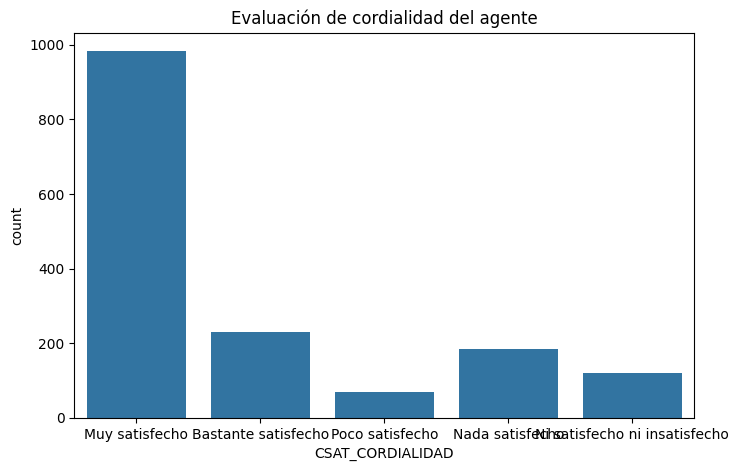

In [142]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df_clean,
x='CSAT_CORDIALIDAD'
)

plt.title("Evaluación de cordialidad del agente")

plt.show()

# **Principales hallazgos**

La distribución del NPS muestra que las respuestas de los clientes se concentran principalmente en valores medios y altos, aunque también existen evaluaciones negativas que representan oportunidades de mejora.

Los casos que fueron resueltos presentan niveles más altos de recomendación en comparación con aquellos que no lograron resolverse.

La percepción de demora en la atención aparece como un factor relevante en la experiencia del cliente.

La cordialidad del agente es un componente importante de la satisfacción general del cliente.

Estos resultados sugieren que mejorar la resolución de casos y mantener altos estándares de atención puede tener un impacto positivo en la experiencia del cliente.

# **Conclusión**

El análisis permite observar que la resolución del caso, la percepción de demora y la cordialidad del agente influyen en la experiencia del cliente. Estos factores representan áreas clave donde las organizaciones pueden enfocar sus esfuerzos para mejorar la satisfacción y la recomendación del servicio.